# Email Spam Classification

# Importing Libraries

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

# Loading the Dataset

In [3]:
data = pd.read_csv('data/emails.csv')

# Exploratory Data Analysis

In [4]:
data.shape

(5172, 3002)

In [5]:
data.head(10)

,Email No.,the,to,ect,and,for,of,a,you,hou,...,connevey,jay,valued,lay,infrastructure,military,allowing,ff,dry,Prediction
0,Email 1,0,0,1,0,0,0,2,0,0,...,0,0,0,0,0,0,0,0,0,0
1,Email 2,8,13,24,6,6,2,102,1,27,...,0,0,0,0,0,0,0,1,0,0
2,Email 3,0,0,1,0,0,0,8,0,0,...,0,0,0,0,0,0,0,0,0,0
3,Email 4,0,5,22,0,5,1,51,2,10,...,0,0,0,0,0,0,0,0,0,0
4,Email 5,7,6,17,1,5,2,57,0,9,...,0,0,0,0,0,0,0,1,0,0
5,Email 6,4,5,1,4,2,3,45,1,0,...,0,0,0,0,0,0,0,0,0,1
6,Email 7,5,3,1,3,2,1,37,0,0,...,0,0,0,0,0,0,0,0,0,0
7,Email 8,0,2,2,3,1,2,21,6,0,...,0,0,0,0,0,0,0,1,0,1
8,Email 9,2,2,3,0,0,1,18,0,0,...,0,0,0,0,0,0,0,0,0,0
9,Email 10,4,4,35,0,1,0,49,1,16,...,0,0,0,0,0,0,0,0,0,0


In [6]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5172 entries, 0 to 5171
Columns: 3002 entries, Email No. to Prediction
dtypes: int64(3001), object(1)
memory usage: 118.5+ MB


In [7]:
data.isnull().sum()

Email No.     0
the           0
to            0
ect           0
and           0
             ..
military      0
allowing      0
ff            0
dry           0
Prediction    0
Length: 3002, dtype: int64

In [8]:
data.duplicated().sum()

np.int64(0)

In [9]:
data['Prediction'].value_counts()

Prediction
0    3672
1    1500
Name: count, dtype: int64

<Axes: xlabel='Prediction', ylabel='count'>

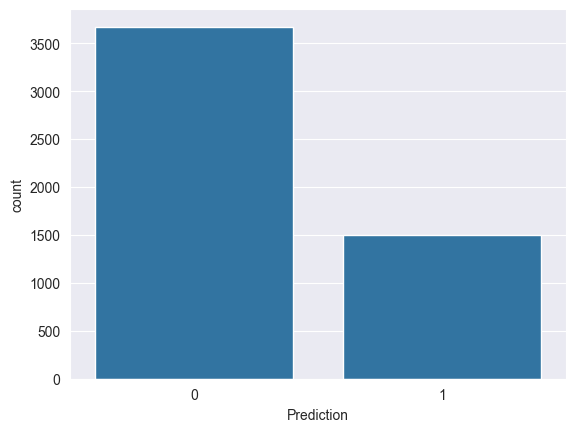

In [10]:
data['Prediction'].value_counts(normalize=True) * 100
sns.countplot(x='Prediction', data=data)


# Data Preprocessing

In [17]:
X = data.drop(['Email No.','Prediction'], axis=1)
y = data['Prediction']

In [18]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=0.2, random_state=42)

In [19]:
X_train

,the,to,ect,and,for,of,a,you,hou,in,...,enhancements,connevey,jay,valued,lay,infrastructure,military,allowing,ff,dry
3164,6,4,2,1,2,8,39,5,2,5,...,0,0,0,0,0,0,0,0,1,0
2067,0,0,1,0,1,0,3,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4717,40,28,4,21,12,12,260,24,4,78,...,0,0,0,0,0,0,0,0,3,0
2505,5,1,1,0,1,1,12,0,0,3,...,0,0,0,0,0,0,0,0,0,0
2268,6,6,3,1,1,0,64,0,1,7,...,0,0,0,0,1,0,0,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4426,0,3,2,0,2,0,16,0,0,1,...,0,0,0,0,0,0,0,0,0,0
466,4,5,1,0,5,1,28,1,0,1,...,0,0,0,0,0,0,0,0,0,0
3092,0,0,1,0,1,0,5,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3772,2,11,1,6,4,5,58,10,0,12,...,0,0,0,0,0,0,0,0,3,0


In [20]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)

X_train_res, y_train_res = smote.fit_resample(X_train, y_train)

print("Avant SMOTE :", y_train.value_counts())
print("Après SMOTE :", y_train_res.value_counts())


Avant SMOTE : Prediction
0    2933
1    1204
Name: count, dtype: int64
Après SMOTE : Prediction
1    2933
0    2933
Name: count, dtype: int64


# Model Training and Evaluation

In [21]:
from xgboost import XGBClassifier
model = XGBClassifier(use_label_encoder=False, eval_metric='logloss')
model.fit(X_train_res, y_train_res)


C:\Users\Ayman\OneDrive\Desktop\Projects\Email_Spam_Classification\.venv\Lib\site-packages\xgboost\training.py:199: UserWarning: [00:19:42] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


,objective,'binary:logistic'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,'logloss'


In [22]:
model.score(X_train_res, y_train_res)

1.0

In [23]:
model.score(X_test, y_test)

0.9681159420289855

In [24]:
from sklearn.metrics import classification_report, confusion_matrix
y_pred = model.predict(X_test)
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.99      0.96      0.98       739
           1       0.91      0.99      0.95       296

    accuracy                           0.97      1035
   macro avg       0.95      0.97      0.96      1035
weighted avg       0.97      0.97      0.97      1035



# Saving the Model

In [25]:
import joblib
joblib.dump(model, 'email_spam_classifier_model.pkl')

['email_spam_classifier_model.pkl']